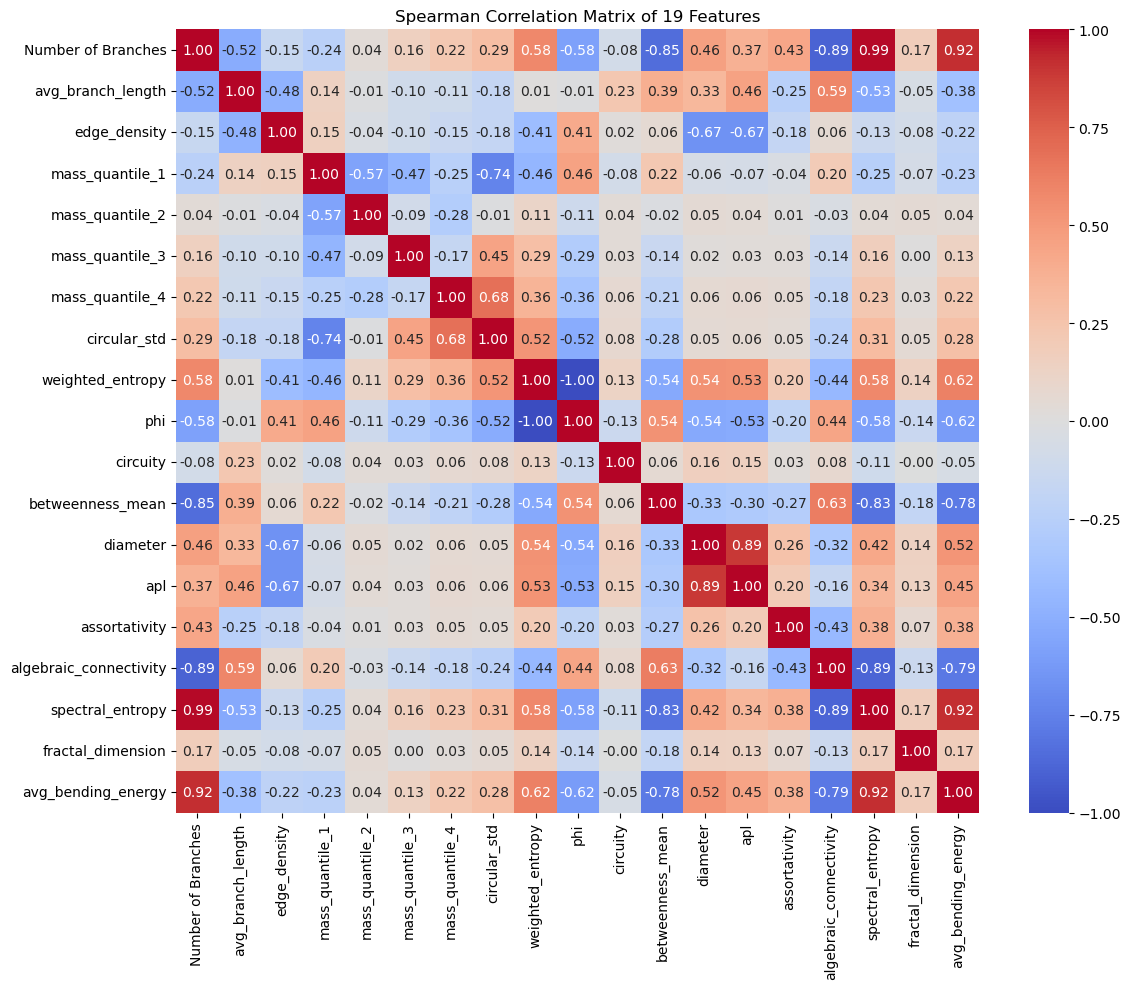

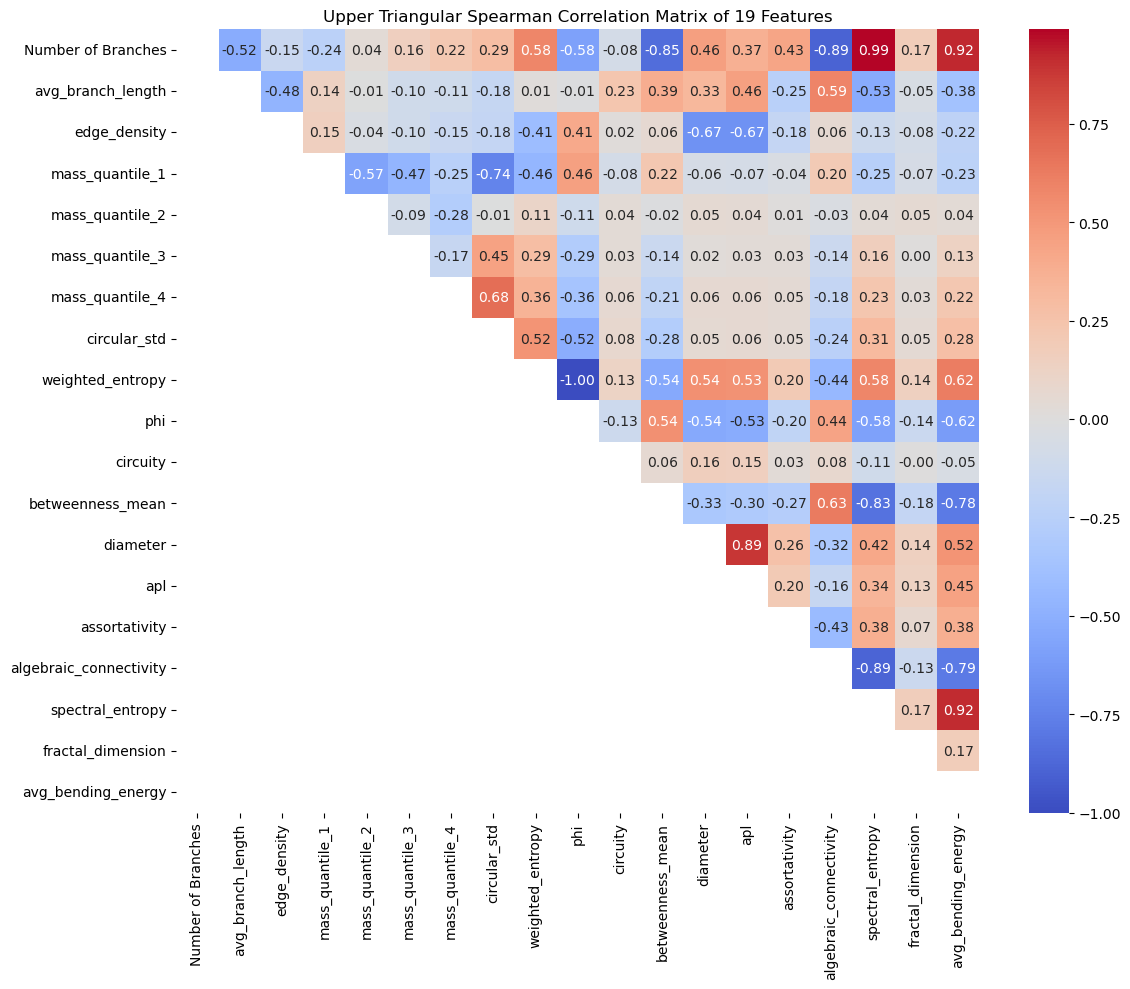

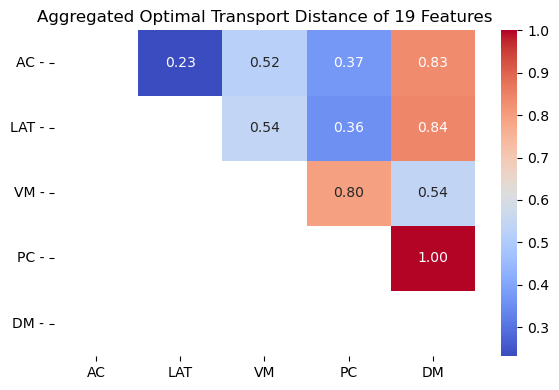

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pickle
import seaborn as sns
import ot
import pandas as pd
from scipy.stats import spearmanr
from scipy.spatial import ConvexHull
from scipy import linalg
from sklearn.preprocessing import MinMaxScaler

core_path = '../graph_single_mask/'

folders = ['ac_control', 'lat_control', 'vm_control', 'pc_control', 'dm_control']



display_names = {
    'ac_control': 'AC',
    'lat_control': 'LAT',
    'vm_control': 'VM',
    'pc_control': 'PC',
    'dm_control': 'DM'
}

display_folders = [display_names[folder] for folder in folders]

interval_labels = ['[3π/8,5π/8]', '[π/4,3π/8]∪[5π/8,3π/4]', '[π/8,π/4]∪[3π/4,7π/8]', '[0,π/8]∪[7π/8,π]']
n = 5

# Load the precomputed features from CSV
df = pd.read_csv('astro_features.csv')

# Map labels back to folders
label_to_folder = {
    0: 'ac_control',  # AC
    1: 'dm_control',  # DM
    2: 'lat_control', # LAT
    3: 'vm_control',  # VM
    4: 'pc_control'   # PC
}

# Feature names mapping from CSV columns to internal names
feature_mapping = {
    'number_of_branches': 'Number of Branches',
    'mean_branch_length': 'avg_branch_length',
    'edge_density': 'edge_density',
    'mass1': 'mass_quantile_1',
    'mass2': 'mass_quantile_2',
    'mass3': 'mass_quantile_3',
    'mass4': 'mass_quantile_4',
    'circular_std': 'circular_std',
    'weighted_entropy': 'weighted_entropy',
    'phi': 'phi',
    'circuity': 'circuity',
    'mean_betweenness': 'betweenness_mean',
    'diameter': 'diameter',
    'apl': 'apl',
    'assortativity': 'assortativity',
    'algebraic_connectivity': 'algebraic_connectivity',
    'spectral_entropy': 'spectral_entropy',
    'fractal_dimension': 'fractal_dimension',
    'avg_bending_energy': 'avg_bending_energy'
}

feature_names = list(feature_mapping.values())

# Initialize feature_data
feature_data = {feat: {folder: [] for folder in folders} for feat in feature_names}

# Group by label and populate feature_data
grouped = df.groupby('label')
for label, group in grouped:
    folder = label_to_folder.get(label)
    if folder:
        for csv_name, feat_name in feature_mapping.items():
            feature_data[feat_name][folder] = group[csv_name].tolist()

# Apply Min-Max normalization to features
scaler = MinMaxScaler()
for feat_name in feature_data.keys():
    # Combine all folder data for this feature
    all_values = []
    for folder in folders:
        all_values.extend(feature_data[feat_name][folder])
    all_values = np.array(all_values)
    # Check if max > 1
    if len(all_values) > 0 and np.max(all_values) > 1:
        all_values_reshaped = all_values.reshape(-1, 1)
        normalized_values = scaler.fit_transform(all_values_reshaped).flatten()
        # Redistribute normalized values back to folders
        start_idx = 0
        for folder in folders:
            num_values = len(feature_data[feat_name][folder])
            feature_data[feat_name][folder] = normalized_values[start_idx:start_idx + num_values].tolist()
            start_idx += num_values

# Compute Spearman correlation matrix
conc_feature_for_corr = []
for folder in folders:
    folder_features = np.array([
        feature_data[feat][folder] for feat in feature_names
    ]).T  # Shape: (n_graphs, 19)
    conc_feature_for_corr.append(folder_features)
conc_feature_for_corr = np.vstack(conc_feature_for_corr)  # Shape: (total_graphs, 19)
corr_matrix = np.zeros((19, 19))
for i in range(19):
    for j in range(19):
        corr_index, _ = spearmanr(conc_feature_for_corr[:, i], conc_feature_for_corr[:, j], nan_policy='omit')
        corr_matrix[i, j] = corr_index if not np.isnan(corr_index) else 0

# Plot full correlation matrix heatmap (upper and lower triangles)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", xticklabels=feature_names, yticklabels=feature_names)
plt.title("Spearman Correlation Matrix of 19 Features")
plt.savefig('Spearman Correlation Matrix of 19 Features.png')
plt.tight_layout()
plt.show()

# Plot upper triangular correlation matrix heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_matrix_upper = np.where(mask, corr_matrix, np.nan)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_upper, annot=True, cmap='coolwarm', fmt=".2f", xticklabels=feature_names, yticklabels=feature_names)
plt.title("Upper Triangular Spearman Correlation Matrix of 19 Features")
plt.tight_layout()
plt.show()

# Upper-triangular function for OT distance
def upper_triangular(df):
    mask = np.triu(np.ones(df.shape), k=1).astype(bool)
    df_upper = df.where(mask)
    return df_upper

# 1D OT distance function
def compute_ot_distance_1d(data1, data2, num_bins=20):
    if not data1 or not data2 or np.any(np.isnan(data1)) or np.any(np.isnan(data2)):
        return np.nan
    min_val = min(np.min(data1), np.min(data2))
    max_val = max(np.max(data1), np.max(data2))
    if min_val == max_val:
        return 0.0
    bins = np.linspace(min_val, max_val, num_bins + 1)
    hist1, _ = np.histogram(data1, bins=bins, density=False)
    hist2, _ = np.histogram(data2, bins=bins, density=False)
    if np.sum(hist1) == 0 or np.sum(hist2) == 0:
        return np.nan
    hist1 = hist1 / np.sum(hist1)
    hist2 = hist2 / np.sum(hist2)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    M = ot.dist(bin_centers.reshape(-1, 1), bin_centers.reshape(-1, 1), metric='euclidean')
    return ot.emd2(hist1, hist2, M)

# Compute OT distances for each feature
distance_matrix_all_features = np.zeros((19, 5, 5))
for feat_idx, feat_name in enumerate(feature_names):
    for i, folder1 in enumerate(folders):
        for j, folder2 in enumerate(folders):
            data1 = feature_data[feat_name][folder1]
            data2 = feature_data[feat_name][folder2]
            if len(data1) > 0 and len(data2) > 0:
                dist = compute_ot_distance_1d(data1, data2)
                distance_matrix_all_features[feat_idx, i, j] = dist if not np.isnan(dist) else 0

# Aggregated OT distance
I19 = np.eye(19)
tot_distance_matrix = np.zeros((5, 5))
for i in range(19):
    single_feat_distance_matrix = distance_matrix_all_features[i, :, :]
    for k in range(5):
        for l in range(5):
            dist_single_feature = single_feat_distance_matrix[k, l]
            for j in range(i, 19):
                dist_single_feat_vs_rest = distance_matrix_all_features[j, k, l]
                value = I19[i, j] - ((1/19) * np.abs(corr_matrix[i, j] - I19[i, j]))
                tot_distance_matrix[k, l] += dist_single_feature * value * dist_single_feat_vs_rest

# Apply square root transformation (as in original code)
tot_distance_matrix = np.sqrt(tot_distance_matrix)

# Normalize by dividing by the maximum value
tot_distance_matrix /= np.max(tot_distance_matrix)

# Create upper triangular matrix for visualization
df_distances = pd.DataFrame(tot_distance_matrix, index=display_folders, columns=display_folders)
df_distances_upper = upper_triangular(df_distances)

# Plot OT distance heatmap using sns.heatmap
plt.figure(figsize=(6, 4))
ax = sns.heatmap(df_distances_upper, annot=True, cmap='coolwarm', fmt=".2f", mask=df_distances_upper.isnull())
ax.set_yticklabels([f"{lab} -" for lab in display_folders], rotation=0)
plt.title("Aggregated Optimal Transport Distance of 19 Features")
# plt.ylabel("Folder 1")
# plt.xlabel("Folder 2")
plt.tight_layout()
plt.savefig('ot_distance_heatmap.png', dpi=300)
plt.show()